In [606]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")
from pathlib import Path
import joblib

from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    cross_val_predict,
)


from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
RANDOM_SEED = 42

In [607]:
df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [608]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Saknade värden

In [609]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

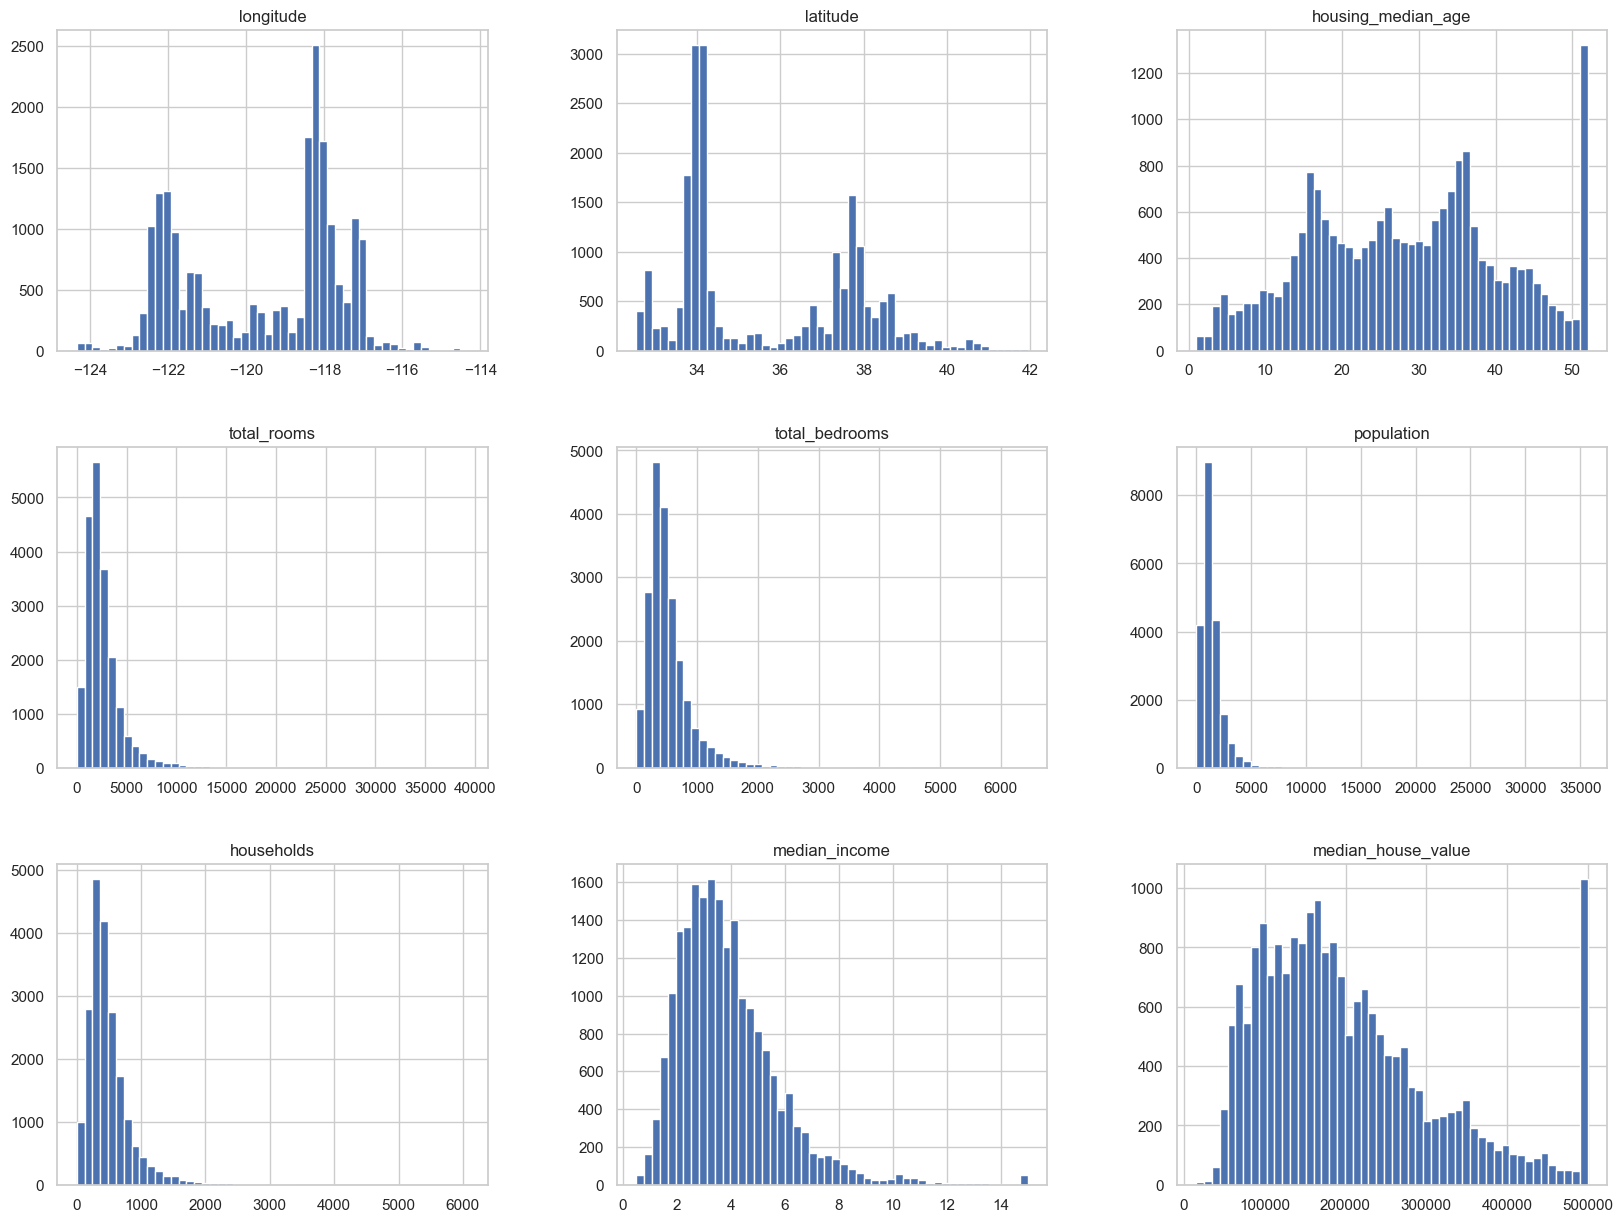

In [610]:
df.hist(bins=50, figsize=(20,15))
plt.show()


I boken tog dom upp att olika features har ett tak och tittar vi på median house value ser vi tydligt var gränsen går. 

In [611]:
df["median_house_value"].value_counts().sort_index(ascending=False).head()

median_house_value
500001.0    965
500000.0     27
499100.0      1
499000.0      1
498800.0      1
Name: count, dtype: int64

Housing_median_age har också ett tak på 52år viket vi tydligt ser i resultatet nedan

In [612]:
df["housing_median_age"].value_counts().sort_index(ascending=False).head()

housing_median_age
52.0    1273
51.0      48
50.0     136
49.0     134
48.0     177
Name: count, dtype: int64

Sist men inte minst så har median income också ett tak på både en nedre gräns på 0.49.. och en övre gräns på 49.

In [613]:
print("Nedre gräns",df["median_income"].value_counts().sort_index(ascending=True).head())
print("Övre gräns",df["median_income"].value_counts().sort_index(ascending=False).head())

Nedre gräns median_income
0.4999    12
0.5360    10
0.5495     1
0.6433     1
0.6775     1
Name: count, dtype: int64
Övre gräns median_income
15.0001    49
15.0000     2
14.9009     1
14.5833     1
14.4219     1
Name: count, dtype: int64


In [614]:
mask = (
    (df["median_house_value"] < 500000) &
    (df["housing_median_age"] < 52) &
    (df["median_income"] >= 0.5) &
    (df["median_income"] <= 15)
)

df = df[mask]



In [615]:

corr_matrix = df.select_dtypes(include=["number"]).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.664747
total_rooms           0.153854
households            0.100471
total_bedrooms        0.079807
population            0.022386
housing_median_age    0.014217
longitude            -0.022921
latitude             -0.171532
Name: median_house_value, dtype: float64

Här gör vi en snabb analys av korrelationen mellan de olika features och target-värdet. Vi ser tydligt att medianinkomsten har högst korrelation, och därför använder vi den som stratifieringsvariabel när vi delar upp datan i tränings- och testdata.

Jag trodde tidigare att stratifiering bara användes vid klassificering, men boken förklarar att man även kan stratifiera en variabel som korrelerar starkt med target-värdet i regressionsproblem.

Vi delar därför in medianinkomsten i fem intervall (grupper). Fördelningen av dessa grupper ska sedan vara ungefär lika i både träningsdatan och testdatan. Detta gör att testdatan blir mer representativ för hela datasetet.

In [616]:
df["income_cat"] = np.ceil(df["median_income"] / 1.5)
df.loc[df["income_cat"] >= 5, "income_cat"] = 5.0
stratifyed_label = df["income_cat"]

## Nya colummer

In [617]:
df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"]=df["population"]/df["households"]
df["log_population"] = np.log1p(df["population"])

Original-features beskriver mest storlek och mängd, men säger inte så mycket om hur människor bor. Genom att skapa features som rooms_per_household och bedrooms_per_room får man variabler som bättre beskriver storleken på hushållet samt boendestandard, vilket är mer relevant för att förklara huspriser.
Jag la även till log(populationen) eftersom Log-transformering gör relationen mer linjär och förbättrar modellens stabilitet.

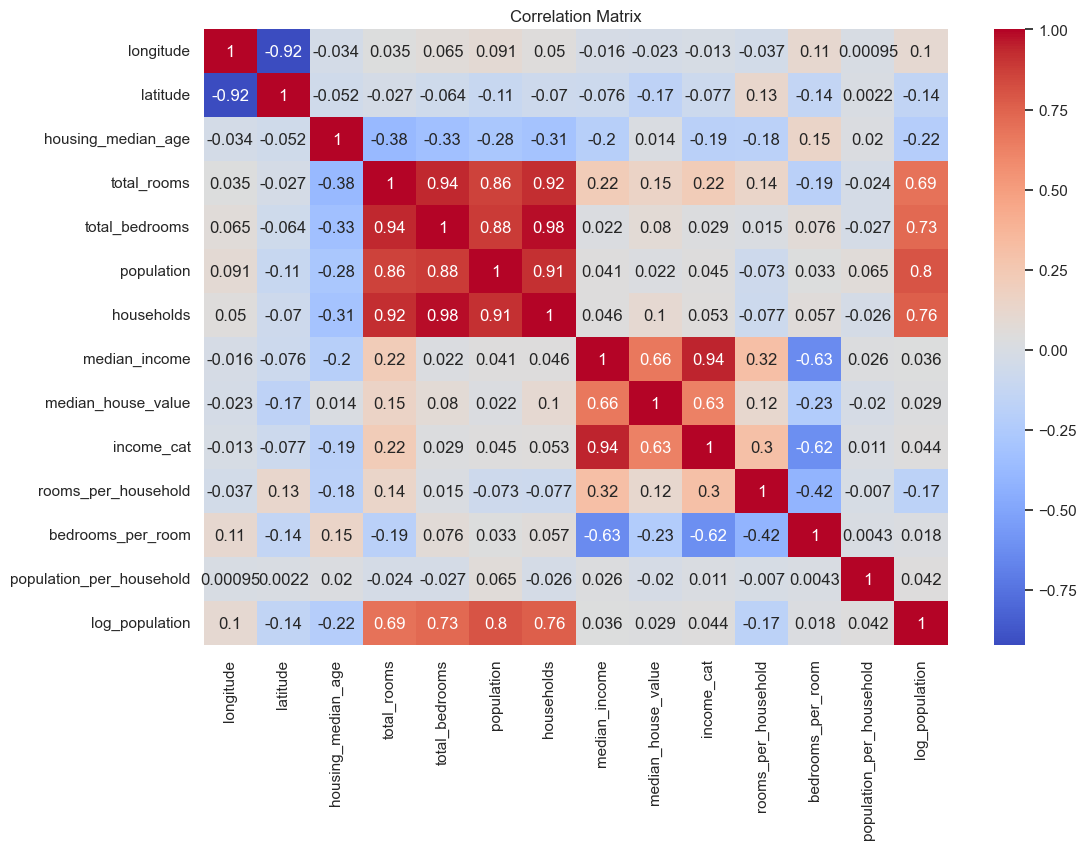

In [618]:


numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,      
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Kontrollerar att de nya features inte har hög korrelation med andra variabler. Om två variabler är starkt korrelerade bör en av dem tas bort eftersom det kan skapa multikollinearitet. När två features innehåller samma information kommer den informationen att räknas flera gånger i avståndsberäkningen, vilket gör att dessa variabler får större vikt i klustringen. Multikollinearitet kan även göra att man tolkar regressionen fel eftersom det blir svårt att avgöra vilka variabler som faktiskt påverkar modellen mest.
Vi ser tydligt att total_bedrooms, total_rooms, population samt households har hög korrelation med varandra. Tidigare skapade vi fyra nya features som kombinerar dessa variabler för att få en bättre inblick i datan. I vårt fall är det därför bäst att ta bort de ursprungliga variablerna och istället använda de nya features.

## Avtånd till kusten

Den här koden är hämtad från nätet och används för att beräkna avståndet till kusten, i stället för att använda variabeln ocean_proximity. Anledningen till att jag valde denna lösning är att KMeans fungerade betydligt bättre med en numerisk feature som distance_to_coast än med ocean_proximity, som först behövde one-hot-enkodas. Eftersom KMeans bygger på avstånd mellan numeriska variabler blev den här representationen mer naturlig och gav bättre kluster som ni kommer se senare.

In [619]:

from sklearn.neighbors import BallTree

ca_coastline = np.array([
    [-124.35, 42.00],  
    [-124.20, 41.50],
    [-124.15, 41.00],
    [-124.10, 40.50],
    [-124.05, 40.00],
    [-124.00, 39.50],
    [-123.95, 39.00],
    [-123.85, 38.60],
    [-123.70, 38.20],
    [-123.55, 37.90],
    [-123.35, 37.65],
    [-123.10, 37.45],
    [-122.75, 37.20],
    [-122.55, 37.00],
    [-122.45, 36.80],
    [-122.30, 36.50],
    [-122.10, 36.20],
    [-121.95, 35.95],
    [-121.85, 35.70],
    [-121.75, 35.40],
    [-121.55, 35.10],
    [-121.20, 34.80],
    [-120.85, 34.55],
    [-120.50, 34.35],
    [-120.10, 34.20],
    [-119.80, 34.10],
    [-119.55, 34.00],
    [-119.30, 33.90],
    [-119.00, 33.82],
    [-118.70, 33.75],
    [-118.50, 33.68],
    [-118.30, 33.62],
    [-118.10, 33.55],
    [-117.95, 33.45],
    [-117.80, 33.30],
    [-117.55, 33.10],
    [-117.35, 32.90],
    [-117.13, 32.53], 
])


def densify_polyline(coords, points_per_segment=50):
    dense_points = []
    for i in range(len(coords) - 1):
        start = coords[i]
        end = coords[i + 1]
        lons = np.linspace(start[0], end[0], points_per_segment, endpoint=False)
        lats = np.linspace(start[1], end[1], points_per_segment, endpoint=False)
        segment_points = np.column_stack([lons, lats])
        dense_points.append(segment_points)
    dense_points.append(coords[-1].reshape(1, 2))
    return np.vstack(dense_points)

dense_coast = densify_polyline(ca_coastline, points_per_segment=50)


EARTH_RADIUS_KM = 6371.0088

coast_latlon_rad = np.radians(dense_coast[:, [1, 0]])  # [lat, lon]
tree = BallTree(coast_latlon_rad, metric="haversine")

house_latlon_rad = np.radians(df[["latitude", "longitude"]].values)
dist_rad, idx = tree.query(house_latlon_rad, k=1)

df["distance_to_coast_km"] = dist_rad[:, 0] * EARTH_RADIUS_KM




In [ ]:



num_cols = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms',
    'total_bedrooms', 'population', 'households', 'median_income',
    "rooms_per_household" ,"bedrooms_per_room",
    "population_per_household",'distance_to_coast_km',"log_population"
    
    ]

cat_cols = ['ocean_proximity']


drop_columns = [
    'median_house_value',
    'total_bedrooms', 
    'population', 
    'households',
    'total_rooms',
    'ocean_proximity'
    ]


X = df.drop(columns= drop_columns)
y = df['median_house_value']


columns_used = [c for c in X.columns if c not in drop_columns]


In [621]:
columns_used

['longitude',
 'latitude',
 'housing_median_age',
 'median_income',
 'ocean_proximity',
 'income_cat',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household',
 'log_population',
 'distance_to_coast_km']

## Delar datan i train och test

In [646]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state= RANDOM_SEED,
    stratify=stratifyed_label
)

print(X_train["income_cat"].value_counts() / len(X_train))
print(X_test["income_cat"].value_counts() / len(X_test))

X_test.drop("income_cat", axis=1, inplace=True)
X_train.drop("income_cat", axis=1, inplace=True)



income_cat
3.0    0.358722
2.0    0.332098
4.0    0.181720
5.0    0.088231
1.0    0.039229
Name: count, dtype: float64
income_cat
3.0    0.358760
2.0    0.332075
4.0    0.181671
5.0    0.088410
1.0    0.039084
Name: count, dtype: float64


In [623]:
housing = df.copy()
housing["median_house_value"] = y_train

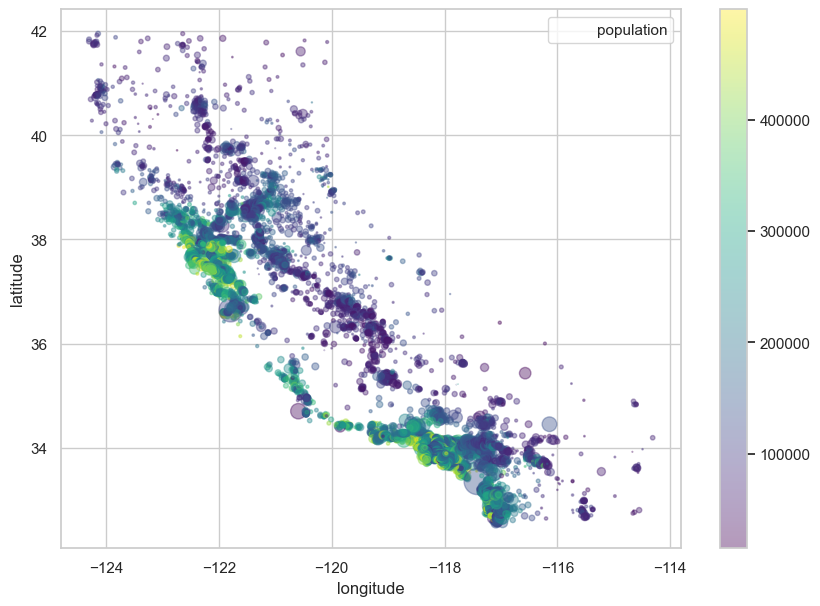

In [624]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c=housing["median_house_value"], cmap="viridis", colorbar=True)

plt.legend()



Grafen visar tydligt att avståndet till havet samt mängden invånare i området stor betydelse för median priset för ett hus.

## PipeLine

In [625]:

selected_num_cols = [x for x in columns_used if x in num_cols]
selected_cat_cols = [x for x in columns_used if x in cat_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])



preprocess = ColumnTransformer([
    ("num", num_pipe, selected_num_cols),
    ("cat", cat_pipe, selected_cat_cols)
])

def make_model(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

In [626]:
lg = LinearRegression()

rf = RandomForestRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1
)

dt = DecisionTreeRegressor(
    random_state=RANDOM_SEED
)

gb = GradientBoostingRegressor(
    random_state=RANDOM_SEED
)

ridge = Ridge(random_state=RANDOM_SEED)

lasso = Lasso(random_state=RANDOM_SEED)

xgb = XGBRegressor(random_state=RANDOM_SEED)

model_dummy = DummyRegressor(strategy="mean")

In [627]:
model_lr = make_model(lg)
model_rf = make_model(rf)
model_dt = make_model(dt)
model_gb = make_model(gb)
model_ridge = make_model(ridge)
model_lasso = make_model(lasso)
model_xgb = make_model(xgb)
model_dummy = make_model(model_dummy)

## Vilken modell presterar bäst på CV?

In [628]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "neg_root_mean_squared_error"

Anledingen till varför vi kör på RMSE är pga den straffar större fel. Detta leder till att den blir känslig för outliers. Vi vill ha en modell som unviker stora misstag.

In [629]:
models = {
    "Dummy": model_dummy,
    "LinearRegression": model_lr,
    "RandomForest": model_rf,
    "DecisionTree": model_dt,
    "GradientBoosting": model_gb,
    "XGBoost": model_xgb,
    "Ridge": model_ridge,
    "Lasso": model_lasso
}


baseline_rows = []

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table

c:\Users\simon\Desktop\ML_Housing\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.948e+12, tolerance: 1.072e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\simon\Desktop\ML_Housing\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.905e+12, tolerance: 1.082e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\simon\Desktop\ML_Housing\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,model,mean,std
5,XGBoost,-40706.718607,1783.071664
2,RandomForest,-42589.347438,1498.440684
4,GradientBoosting,-45869.361531,1288.744916
7,Lasso,-59756.592082,531.556530
6,Ridge,-59756.606098,531.549655
1,LinearRegression,-59756.694135,531.515077
3,DecisionTree,-61152.985901,1175.425521
0,Dummy,-95505.588878,1295.536501


## Top 2 modeller

In [630]:
top2_models = baseline_table["model"].head(2).tolist()
print("top-2 models", top2_models)

best_model = models[top2_models[0]]
second_best_model = models[top2_models[1]]

top-2 models ['XGBoost', 'RandomForest']


## Hyperparametrar för alla modeller

Testade med olika hyperparametrar och dessa blev bäst, tog bort alla dom andra så ni slipper vänta på träningen.

In [666]:
param_rf ={'model__max_depth': [15],
 'model__min_samples_leaf': [4],
 'model__min_samples_split': [2],
 'model__n_estimators': [300]}


param_xgb = {'model__learning_rate': [0.05, 0.1],
 'model__max_depth': [5, 7, 9],
 'model__n_estimators': [300, 400, 500],
 'model__subsample': [0.8, 0.9]}

In [632]:
grid_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_xgb,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
    )

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05], 'model__max_depth': [7], 'model__n_estimators': [500], 'model__subsample': [0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [633]:
grid_xgb.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 7,
 'model__n_estimators': 500,
 'model__subsample': 0.8}

In [634]:
grid_rf = GridSearchCV(
    estimator=model_rf,
    param_grid=param_rf,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
    )

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15], 'model__min_samples_leaf': [4], 'model__min_samples_split': [2], 'model__n_estimators': [300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >

In [635]:
grid_rf.best_params_


{'model__max_depth': 15,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 2,
 'model__n_estimators': 300}

## Bästa modellen



In [636]:
print(grid_xgb.best_score_)
print(grid_rf.best_score_)

if grid_xgb.best_score_ > grid_rf.best_score_:
    print("The winner is Xgboost")
else:
    print("´The winner is: Random Forest")

best_model = grid_xgb if grid_xgb.best_score_ > grid_rf.best_score_ else grid_rf

-39037.31896584714
-42829.03867393834
The winner is Xgboost


## Feature imporance

## Tree importance

In [645]:

model_step = best_model.best_estimator_.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_model.best_estimator_.named_steps["preprocess"].get_feature_names_out()

    importances = model_step.feature_importances_

    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    print(fi)

else:
    print("This model does not support feature_importances_.")


cat__ocean_proximity_INLAND        0.840516
num__median_income                 0.067839
num__distance_to_coast_km          0.017069
num__population_per_household      0.016130
num__latitude                      0.009274
num__longitude                     0.008646
cat__ocean_proximity_NEAR OCEAN    0.008625
cat__ocean_proximity_NEAR BAY      0.006224
num__housing_median_age            0.006123
cat__ocean_proximity_<1H OCEAN     0.005752
num__rooms_per_household           0.005072
num__bedrooms_per_room             0.004652
num__log_population                0.004078
dtype: float32


Tree Feature Importance handlar om hur mycket en feature minskar felet när beslutsträdet gör en split på den variabeln. Om trädet ofta delar upp datan baserat på till exempel median_income, kommer den featuren att få hög betydelse.

Problemet är att feature importance i trädmodeller ofta är biased mot one-hot-enkodade variabler, vilket kan ge en missvisande bild av vilka variabler som faktiskt är viktiga. Även om vi i nuläget inte använder några kategoriska variabler, eftersom ocean_proximity har ersatts med den numeriska variabeln distance_to_coast_km, är detta något som är viktigt att vara medveten om vid användning av kategoriska features tillsammans med trädmodeller

Därför använder vi istället något som kallas Permutation Importance, som mäter hur mycket modellen faktiskt är beroende av en feature genom att slumpmässigt blanda (permutera) värdena för en feature och se hur mycket modellens prestanda försämras.

## Permutation importance

In [638]:

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.Series(result.importances_mean, index=X_test.columns)
importances.sort_values(ascending=False)

longitude                   36653.138474
distance_to_coast_km        34822.482607
median_income               26086.373108
latitude                    20090.008563
population_per_household    12599.179671
bedrooms_per_room            5663.842900
ocean_proximity              5367.299478
rooms_per_household          5098.365280
housing_median_age           4330.699309
log_population                726.048257
dtype: float64

Här säger den att platsen spelar stor roll med hjälp av avståndet till kusten.

## Test datan

RMSE: 38311.23375085703
MAE: 25229.805696175878


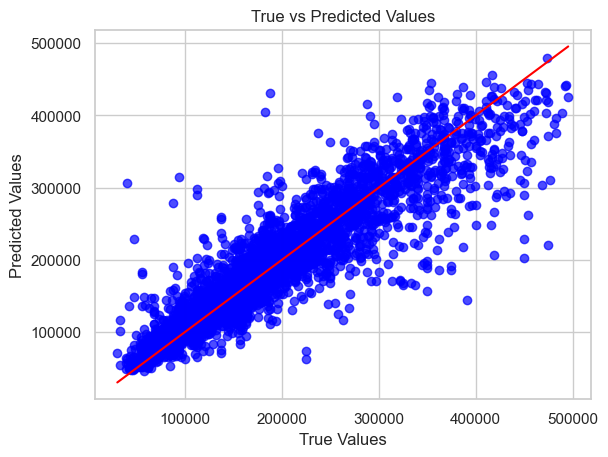

In [639]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.show()

Vi ser tydligt att vår modell presterar bra och att våra prediktioner korrelerar med de sanna värdena. Vi kan också se att felen tenderar att bli större för högre värden. Vi får även en MAE på bara ca 26000 vilket är väldigt bra.

## KMeans


Här skalas kolumnerna och jag väljer vilka features som ska användas för PCA och klustring

In [667]:
X_scaled_full = pd.DataFrame(
    preprocess.fit_transform(X_train),
    columns=preprocess.get_feature_names_out(),
    index=X_train.index
)


X_scaled_full.columns = X_scaled_full.columns.str.replace(r"^.*__", "", regex=True)


features = [
    'median_income',
    "rooms_per_household" ,"bedrooms_per_room",
    "population_per_household", "distance_to_coast_km",
    "log_population"
    
]

X_scaled = X_scaled_full[features]



Testar olika nummer av klusters för att se vilken som ger bäst silhouette score.

,K,inertia,silhouette
0,2,72197.531635,0.248429
1,3,58032.520161,0.248184
2,4,46564.646997,0.292695
3,5,39425.225943,0.301745
4,6,34837.242624,0.245805
5,7,31234.032999,0.248637
6,8,28912.233556,0.243323
7,9,26786.055594,0.246262
8,10,24734.132481,0.248125


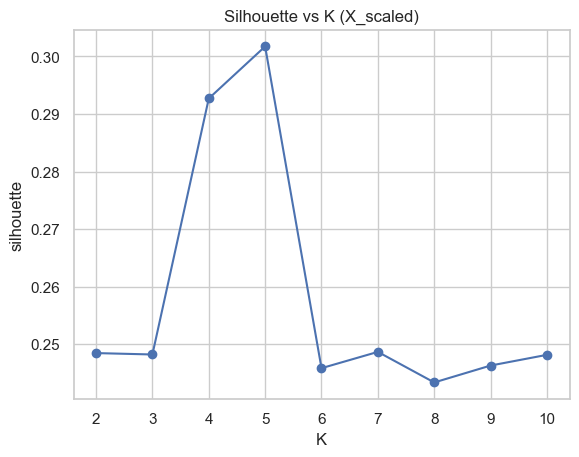

In [668]:

results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({"K": k, "inertia": kmeans.inertia_, "silhouette": score})

results_df =pd.DataFrame(results)
display(results_df)

plt.figure()
plt.plot(results_df["K"], results_df["silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("silhouette")
plt.title("Silhouette vs K (X_scaled)")
plt.grid(True)
plt.show()


Även om K=4 och K=5 hade högre silhouette-värde skapade de väldigt små kluster som i praktiken var outliers. K=3 gav mer balanserade kluster, vilket gör lösningen mer användbar. Man ska därför inte bara titta på silhouette-värdet utan också på hur stora och balanserade klustren är.

In [686]:
K_final = 3

kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(pd.Series(cluster_labels).value_counts().sort_index())

0    3480
1    5740
2    5616
Name: count, dtype: int64


Valde att köra på 3 st klusters då med 5 samt 4 gav clusters som var outliers.

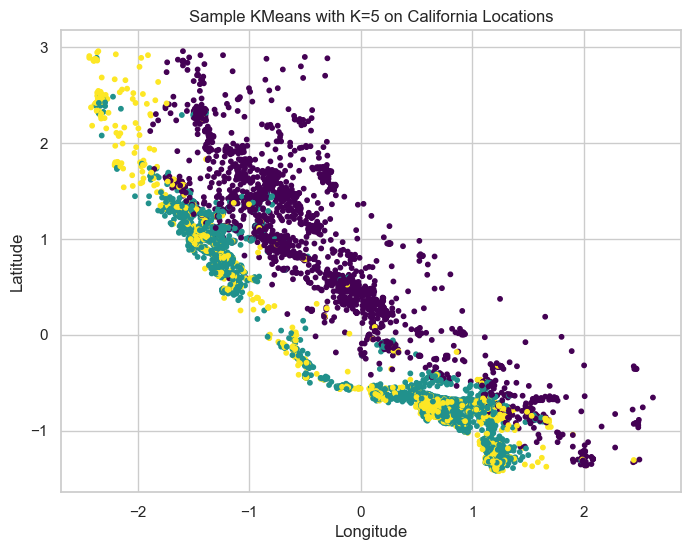

In [687]:

X_scaled_full["cluster"] = cluster_labels

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled_full["longitude"],
    X_scaled_full["latitude"],
    c=X_scaled_full["cluster"],
    cmap="viridis",
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sample KMeans with K=5 on California Locations")
plt.show()

- Cluster 0 → Purple
- Cluster 1 → Green
- Cluster 2 → Yellow

In [689]:

X_scaled["cluster"] = cluster_labels
profile_scaled = X_scaled.groupby("cluster").mean()
display(profile_scaled)

,median_income,rooms_per_household,bedrooms_per_room,population_per_household,distance_to_coast_km,log_population
cluster,,,,,,
0,-0.544231,0.283430,-0.178560,0.000412,1.521307,-0.331414
1,0.932846,0.291231,-0.714285,-0.010623,-0.412999,0.047647
2,-0.616206,-0.473291,0.840703,0.010602,-0.520573,0.156665
